# Introduction

## Description

The heart failure dataset is a comprehencisve collection of medical data specifically designed to facilitate research and analysis in the field of cardiovascular health. It contains a wealth of information gathered from diverse sources, including clinical records, diagnostic tests, and patient demographics. The dataset comprises a substantial number of individuals with heart failure, providing an invaluable resource for studying the prevalent condition and its associated factors.

Downloading the data

In [ ]:
import kagglehub

path = kagglehub.dataset_download("altafk/medical-history-of-heart-failure-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.99k/3.99k [00:00<00:00, 8.97MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/altafk/medical-history-of-heart-failure-dataset/versions/1


Checking what I have downloaded, how the file is called

In [ ]:
!ls  /root/.cache/kagglehub/datasets/altafk/medical-history-of-heart-failure-dataset/versions/1

'medical history_of_heart_failure_Dataset.csv'


# EDA

## importing data

In [ ]:
import pandas as pd

data = pd.read_csv(f'{path}/medical history_of_heart_failure_Dataset.csv')
data.head(3)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.793759,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.715719,0.648829,0.32107,130.260870,0.32107
std,11.802415,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.198448,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,116.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


* age: age in years
* anemia: does have or not anemia
* creatinine_phosphokinase: CPK in blood, mcg/L
* ejection_graction: %, blood fraction leaving the heart per beat
* hbp:does have or not high blood pressure
* platelets: plateletes/mL in blood
* serum?creatininie: mg/Dl
* serum_sodium: Na, mEq/L
* Sex: M = 1, F = 0
* smoking: no/yes
* time: days
* DEATH_EVENT: died or not.

I would like to convert binary variables into BOOL just to ignore them in further data analysis

In [ ]:
for col in data.select_dtypes(include='int64').columns:
    if set(data[col].unique()).issubset({0, 1}):
        data[col] = data[col].astype(bool)

I do not like the max value of creatinine phospokinase, I will check a few max values just to clarify is it an outlier or not.

In [ ]:
data['creatinine_phosphokinase'].nlargest(10)

,creatinine_phosphokinase
1,7861
60,7702
72,5882
103,5209
134,4540
171,3966
52,3964
227,2794
280,2695
38,2656


Ok, seems like it is not an outlier. Checking all the continual variables with box plots for outliers, to be sure that we have a good data for ML and for downstream analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

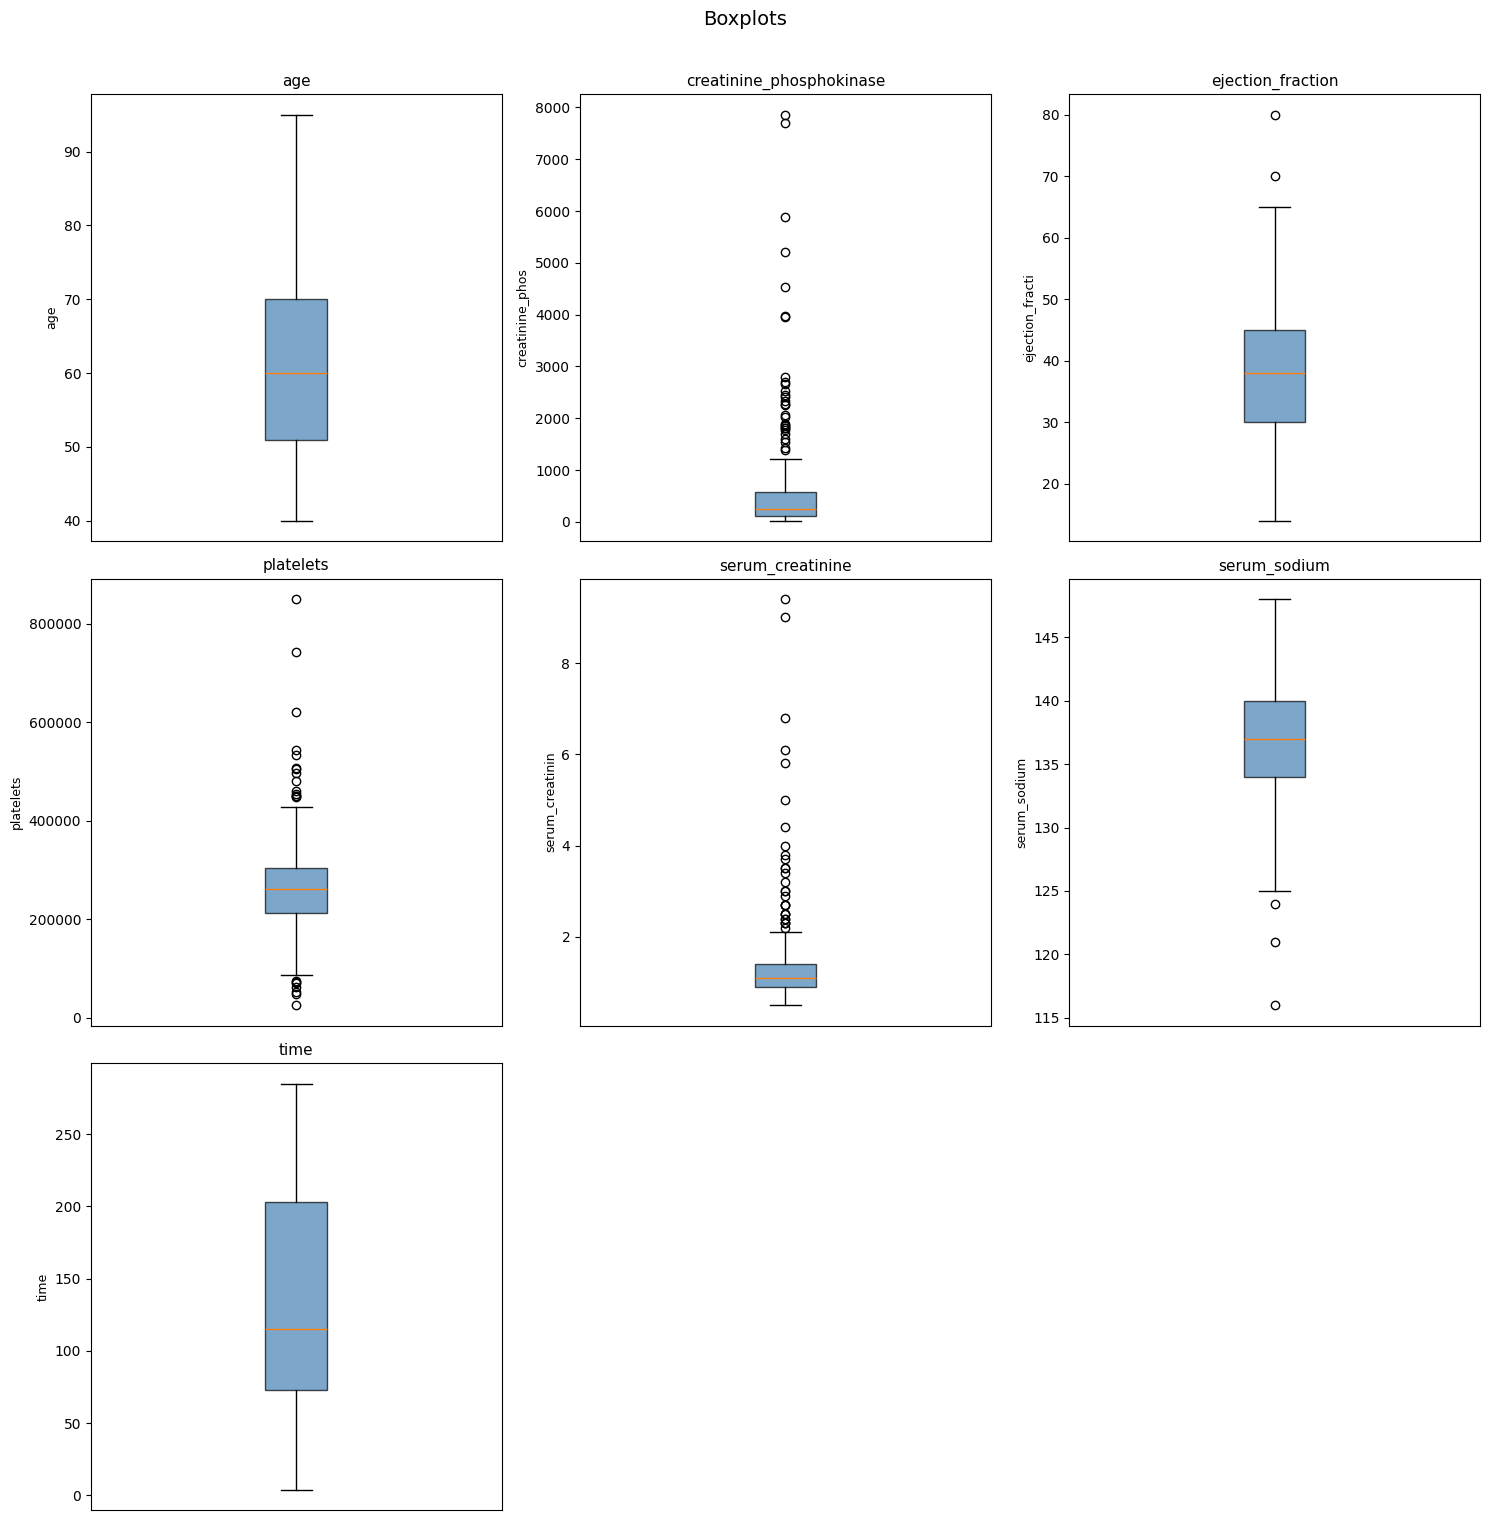

In [ ]:
non_boolian = [c for c in data.columns if data[c].dtype != bool and c != 'DEATH_EVENT']
n = len(non_boolian)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for idx, col in enumerate(non_boolian):
    axes[idx].boxplot(data[col], patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[idx].set_title(col, fontsize=11)
    axes[idx].set_ylabel(col[:15], fontsize=9)
    axes[idx].set_xticks([])

for idx in range(len(non_boolian), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


I see a lot of points out of the 1.5 * interquartile range for creatinine_PCK, serum_creatinine< platelets, I will check them after log transformation, because their distribution seems skewed

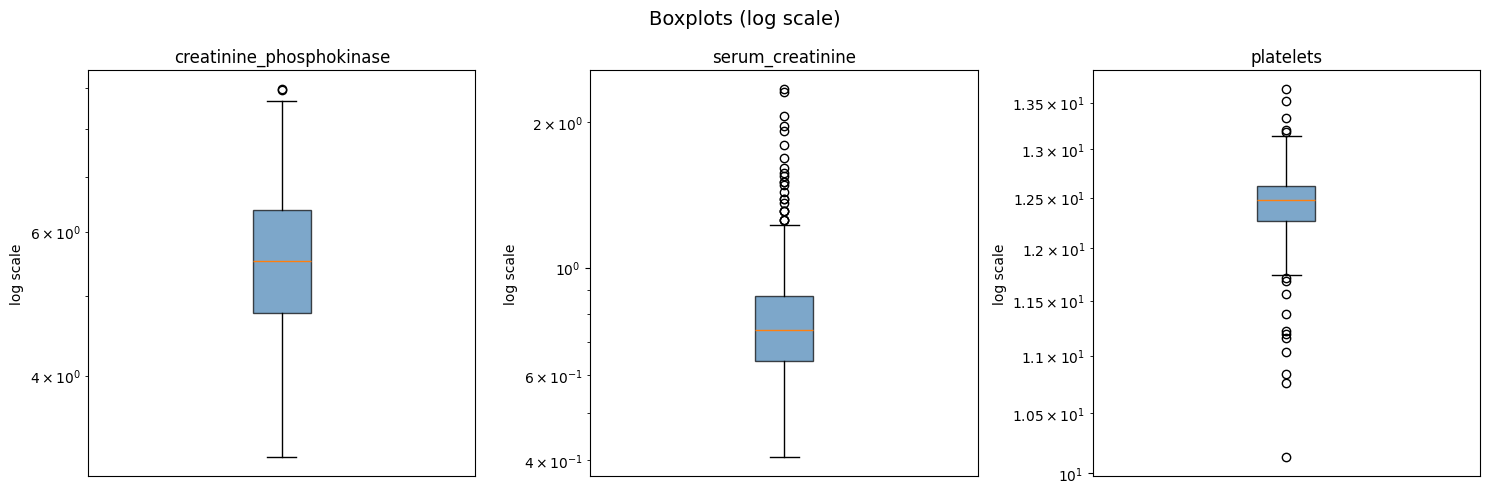

In [ ]:
log_cols = ['creatinine_phosphokinase', 'serum_creatinine', 'platelets']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(log_cols):
    axes[idx].boxplot(np.log1p(data[col]), patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[idx].set_title(col)
    axes[idx].set_yscale('log')
    axes[idx].set_ylabel('log scale')
    axes[idx].set_xticks([])

plt.suptitle('Boxplots (log scale)', fontsize=14)
plt.tight_layout()
plt.show()


I suppose that serum_Creatinine has right_skewed distribution, it is not outliers, but It is probably lognorm distribution, so it is better to use log1p for ML tasks for these varaibles (all of three).

I will use log1p (log(x + 1)) transform for serum_Creatinine, then I will evaluate with Maximum Likelihood Evaluation the mean and std of log-transformed data (I guess log(x + 1) ~ 𝒩(μ, σ)) and show PDF for normal distibution with found parameters.

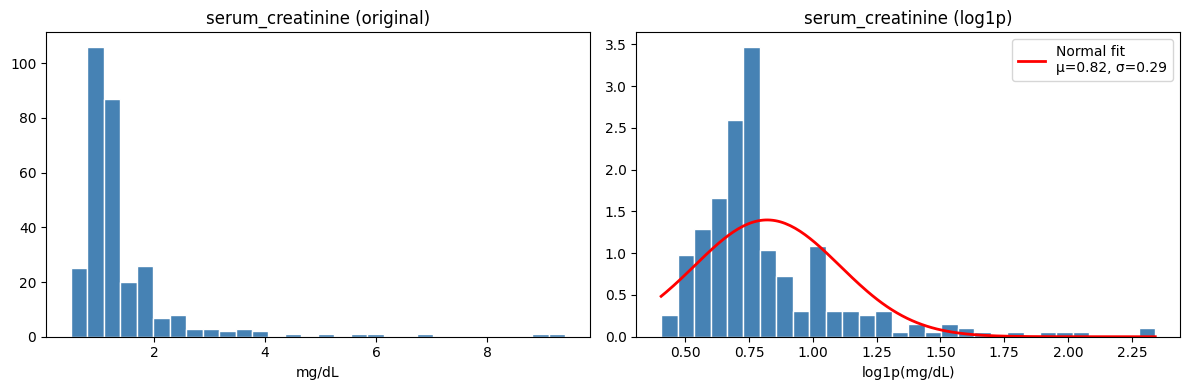

In [ ]:
from scipy import stats

log_vals = np.log1p(data['serum_creatinine'])
mu, sigma = stats.norm.fit(log_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data['serum_creatinine'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('serum_creatinine (original)')
axes[0].set_xlabel('mg/dL')

axes[1].hist(log_vals, bins=30, color='steelblue', edgecolor='white', density=True)

x = np.linspace(log_vals.min(), log_vals.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), color='red', linewidth=2, label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')
axes[1].set_title('serum_creatinine (log1p)')
axes[1].set_xlabel('log1p(mg/dL)')
axes[1].legend()

plt.tight_layout()
plt.show()


Seems that my guess wasn't right. I will not remove the column, but idk what is this.

And the distribution of target, just to check that we will need stratification (we see class disproportion)

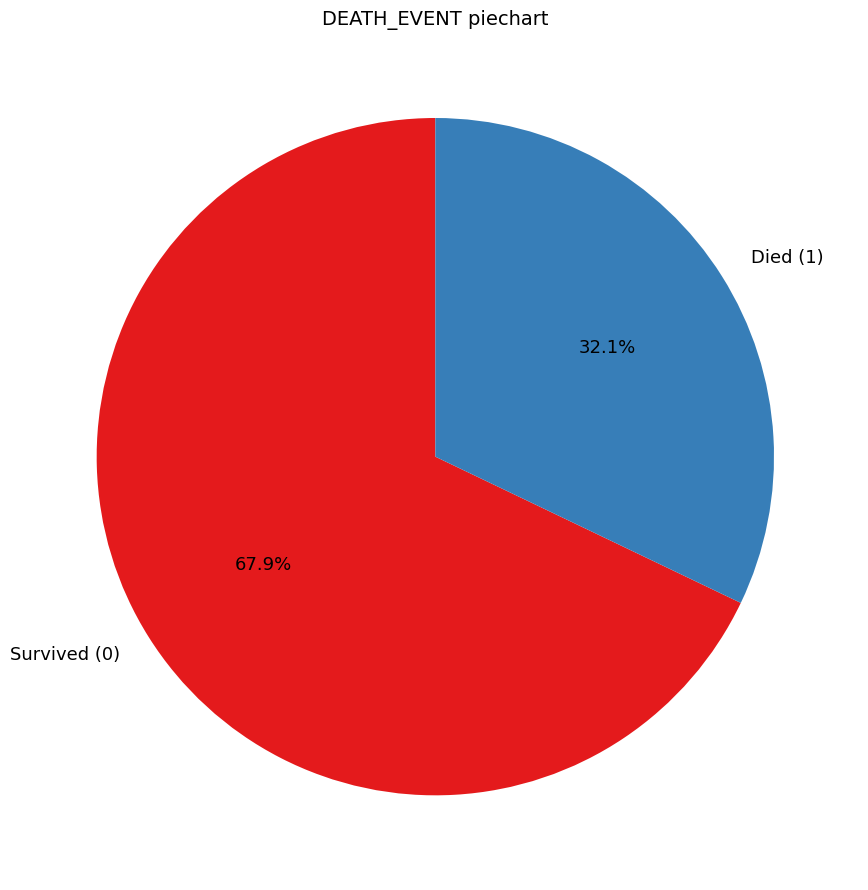

In [ ]:
plt.figure(figsize=(9, 9))
counts = data['DEATH_EVENT'].value_counts()
plt.pie(
    counts,
    labels=['Survived (0)', 'Died (1)'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set1'),
    startangle=90,
    textprops={'fontsize': 13},
)
plt.title('DEATH_EVENT piechart', fontsize=14)
plt.tight_layout()
plt.show()


So we will use all the features, some of them are already binary, some of them have outliers BUT it is not technical outliers, just biological data. Then we need to check relations for data and then try to evaluate our "findings" with predictive probabilities of models, trained on data

# Feature Engineering

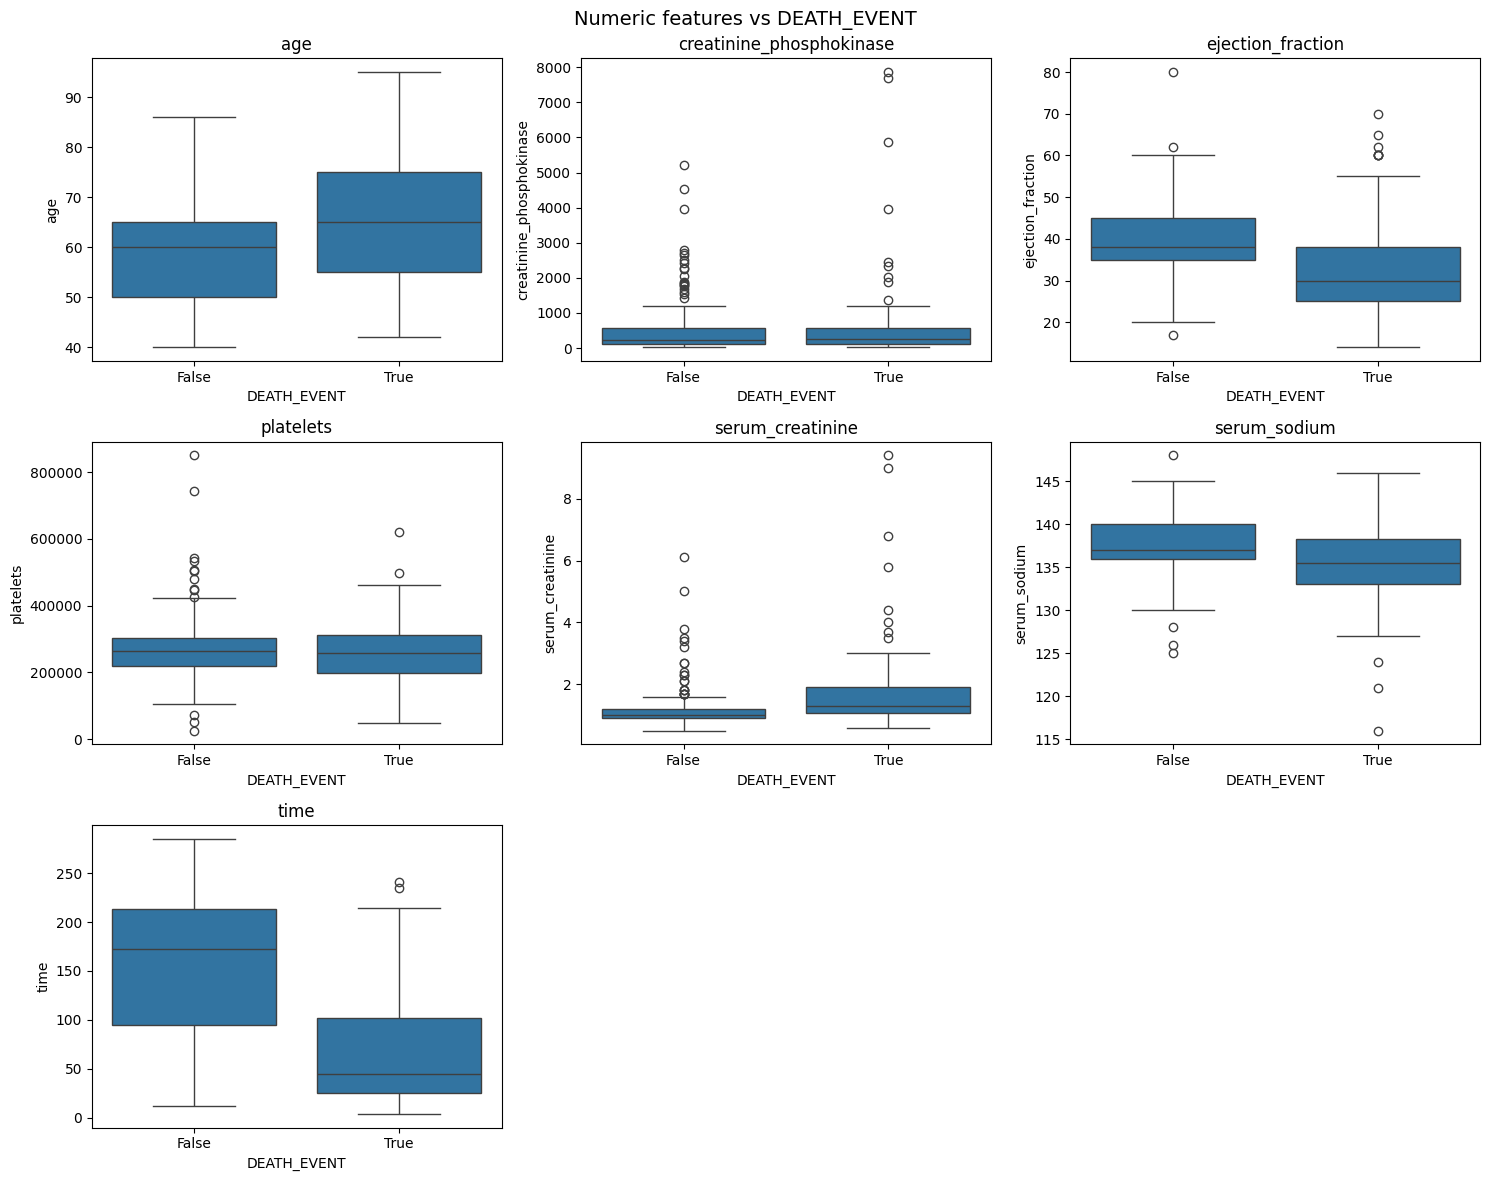

In [ ]:
num_cols = [c for c in data.columns if data[c].dtype != bool and c != 'DEATH_EVENT']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.boxplot(data=data, x='DEATH_EVENT', y=col, ax=axes[idx])
    axes[idx].set_title(col)

for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Numeric features vs DEATH_EVENT', fontsize=14)
plt.tight_layout()
plt.show()

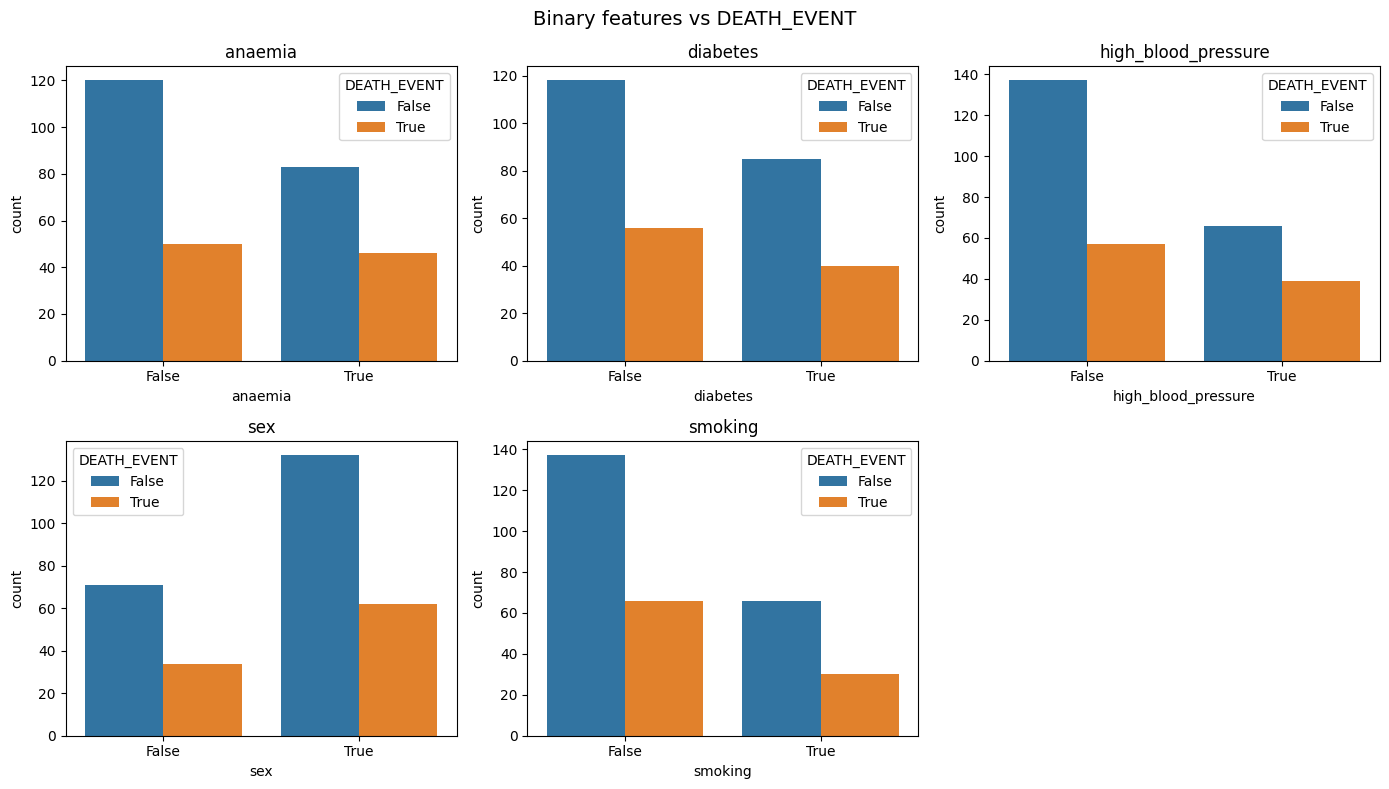

In [ ]:
bool_cols = [c for c in data.columns if data[c].dtype == bool and c != 'DEATH_EVENT']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(bool_cols):
    sns.countplot(data=data, x=col, hue='DEATH_EVENT', ax=axes[idx])
    axes[idx].set_title(col)

for i in range(len(bool_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Binary features vs DEATH_EVENT', fontsize=14)
plt.tight_layout()
plt.show()

For most binary features, the death rate looks similar across both groups:
- anaemia and diabetes show almost no difference; these features
  probably won't help the model much on their own
- high_blood_pressure shows a slight increase in deaths among hypertensive patients.
- sex: female patients (coded as 0) have a proportionally higher death rate
  despite being fewer in the datase
- smoking: non-smokers appear to die more often, may be weak smokers are already dead because of cancer, or, contraversly, they are young and are able to survive, but got this condition because of smoking

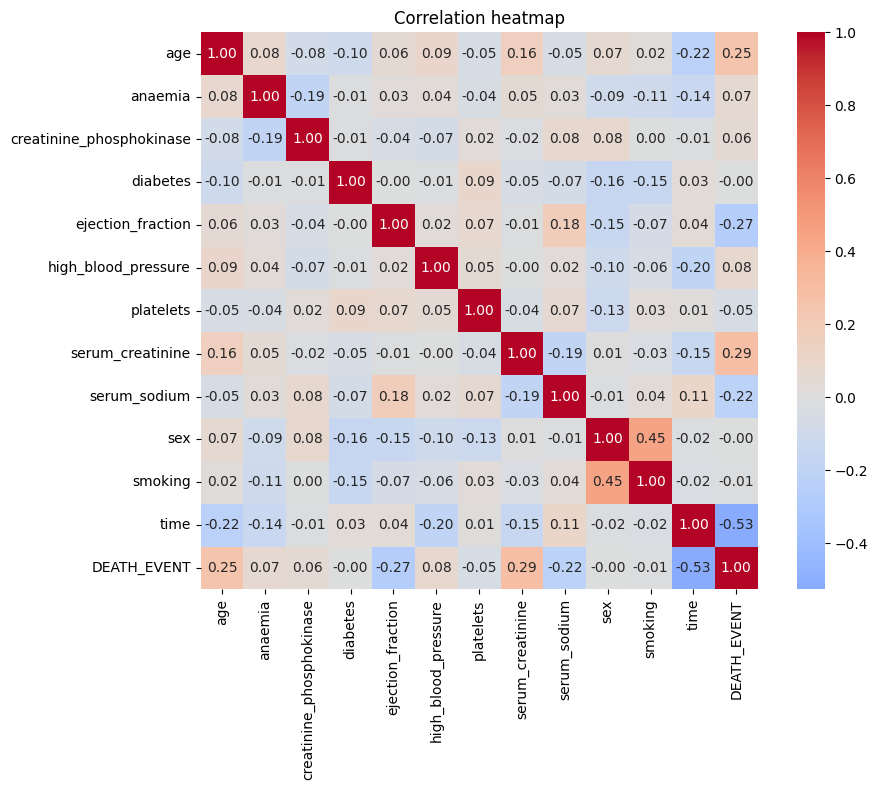

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

The features most related to death are:
- time (–0.53): the longer a patient was followed up, the more likely they survived
- serum_creatinine (+0.29): a kidney function marker. High values suggest the kidneys
  are struggling, which is a known risk factor in heart failure
- ejection_fraction (–0.27): how much blood the heart pumps per beat, low value means the heart is weak - unsurprisingly linked to worse outcomes
- age (+0.25)
- serum_sodium (–0.22): low sodium in the blood is associated with worse heart failur

## Feature Engineering

Based on the EDA above, I want to do the following

- Log-transformed skewed features(`creatinine_phosphokinase`, `serum_creatinine`,
  `platelets`): these had heavy right tails, which can hurt distance-based and linear models.
  Log transformation compresses the scale and makes distributions more symmetric.

- Age groups: age has a non-linear relationship with risk - the jump from 60 to 70
  matters more than from 40 to 50 (we are aging it two bursts)

- Clinical threshold flags:
  - `low_ef`: ejection fraction < 30% - clinically defined as severe systolic dysfunction
  - `high_creatinine`: serum creatinine > 1.5 - a common marker for kidney failure
  - `low_sodium`: serum sodium < 135  - linked to worse heart failure

- Interaction term (`ejection_fraction × serum_creatinine`): both features independently
  predict death. Their product captures the "double risk" scenario - weak heart and
  failing kidneys at the same time.

In [ ]:
data_fe = data.copy()

for col in ['creatinine_phosphokinase', 'serum_creatinine', 'platelets']:
    data_fe[f'{col}_log'] = np.log1p(data_fe[col].astype(float))

data_fe['age_group'] = pd.cut(data_fe['age'],
                               bins=[0, 55, 65, 75, 100],
                               labels=['<55', '55-65', '65-75', '>75'])


data_fe['low_ef'] = (data_fe['ejection_fraction'] < 30).astype(int)
data_fe['high_creatinine'] = (data_fe['serum_creatinine'] > 1.5).astype(int)
data_fe['low_sodium'] = (data_fe['serum_sodium'] < 135).astype(int)

data_fe['ef_x_creatinine'] = data_fe['ejection_fraction'] * data_fe['serum_creatinine']
data_fe.shape


(299, 21)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


              precision    recall  f1-score   support

           0       0.79      0.93      0.85        41
           1       0.75      0.47      0.58        19

    accuracy                           0.78        60
   macro avg       0.77      0.70      0.72        60
weighted avg       0.78      0.78      0.77        60

ROC-AUC: 0.891


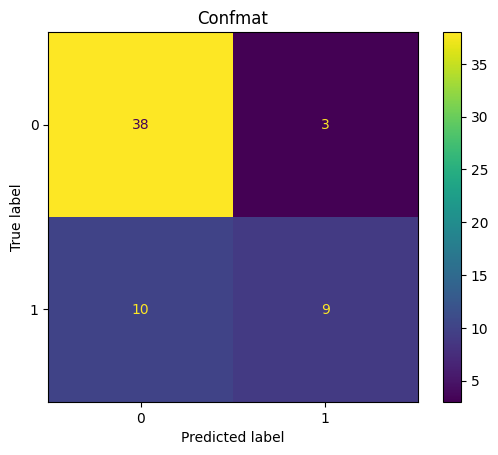

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

X = data_fe.drop(columns='DEATH_EVENT')
y = data_fe['DEATH_EVENT'].astype(int)

cat_features = ['age_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = CatBoostClassifier(verbose=0, random_state=42, cat_features=cat_features)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confmat')
plt.show()